<a href="https://colab.research.google.com/github/hafzafaryad2-eng/data-analytics/blob/main/lab19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "medium_sales_dataset.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "prince7489/retail-sales-forecasting-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_196/994880471.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 94.1k/94.1k [00:00<00:00, 1.37MB/s]

First 5 records:    Item_ID  Item_Weight Item_Fat_Content  Item_Visibility     Item_Type  \
0  ITM0001        11.17          Regular            0.137   Soft Drinks   
1  ITM0002        18.66          Regular            0.214        Canned   
2  ITM0003        17.71          Regular            0.061   Soft Drinks   
3  ITM0004         3.32          Low Fat            0.083         Dairy   
4  ITM0005        13.56          Low Fat            0.103  Baking Goods   

   Item_MRP Outlet_ID  Outlet_Establishment_Year Outlet_Size  \
0     89.68    OUT001                       2013       Small   
1     60.13    OUT002                       2003       Small   
2     26.16    OUT001                       2017       Large   
3     41.75    OUT003                       2018      Medium   
4    427.97    OUT002                       2013       Small   

  Outlet_Location_Type        Outlet_Type  Item_Outlet_Sales  
0               Tier 1  Supermarket Type2            2055.50  
1               Tier 

In [ ]:
df.head(10)

,Item_ID,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_ID,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,ITM0001,11.17,Regular,0.137,Soft Drinks,89.68,OUT001,2013,Small,Tier 1,Supermarket Type2,2055.50
1,ITM0002,18.66,Regular,0.214,Canned,60.13,OUT002,2003,Small,Tier 3,Grocery Store,1863.47
2,ITM0003,17.71,Regular,0.061,Soft Drinks,26.16,OUT001,2017,Large,Tier 2,Grocery Store,1042.87
3,ITM0004,3.32,Low Fat,0.083,Dairy,41.75,OUT003,2018,Medium,Tier 2,Supermarket Type2,1223.59
4,ITM0005,13.56,Low Fat,0.103,Baking Goods,427.97,OUT002,2013,Small,Tier 2,Grocery Store,1437.74
5,ITM0006,17.57,Regular,0.094,Canned,40.37,OUT001,2013,Large,Tier 2,Grocery Store,3038.79
6,ITM0007,8.12,Low Fat,0.172,Frozen Foods,247.08,OUT003,2017,Small,Tier 3,Grocery Store,3007.63
7,ITM0008,14.07,Low Fat,0.105,Frozen Foods,365.00,OUT005,2001,Small,Tier 2,Supermarket Type2,2402.40
8,ITM0009,8.96,Low Fat,0.102,Canned,282.77,OUT003,2005,Small,Tier 1,Supermarket Type1,638.88
9,ITM0010,10.39,Low Fat,0.047,Fruits & Vegetables,283.73,OUT005,1999,Small,Tier 2,Supermarket Type2,3107.64


In [ ]:
df.shape

(1000, 12)

In [ ]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,1000.000000,1000.00000,1000.000000,1000.00000,1000.000000
mean,10.093350,0.13252,261.865990,2009.75400,1825.558570
std,5.664048,0.06749,136.735573,6.32404,855.238856
min,0.510000,0.01000,20.430000,1999.00000,199.340000
25%,5.197500,0.07475,145.245000,2004.00000,1082.572500
50%,9.900000,0.13200,267.740000,2010.00000,1840.645000
75%,15.037500,0.19000,377.080000,2015.00000,2535.600000
max,19.990000,0.25000,499.860000,2020.00000,3651.520000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_ID                    1000 non-null   object 
 1   Item_Weight                1000 non-null   float64
 2   Item_Fat_Content           1000 non-null   object 
 3   Item_Visibility            1000 non-null   float64
 4   Item_Type                  1000 non-null   object 
 5   Item_MRP                   1000 non-null   float64
 6   Outlet_ID                  1000 non-null   object 
 7   Outlet_Establishment_Year  1000 non-null   int64  
 8   Outlet_Size                1000 non-null   object 
 9   Outlet_Location_Type       1000 non-null   object 
 10  Outlet_Type                1000 non-null   object 
 11  Item_Outlet_Sales          1000 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 93.9+ KB


In [ ]:
print("Unique Item Types:")
print(df["Item_Type"].unique())

print("\nUnique Outlet Sizes:")
print(df["Outlet_Size"].unique())

Unique Item Types:
['Soft Drinks' 'Canned' 'Dairy' 'Baking Goods' 'Frozen Foods'
 'Fruits & Vegetables' 'Health and Hygiene' 'Snack Foods' 'Household']

Unique Outlet Sizes:
['Small' 'Large' 'Medium']


In [ ]:
print(df["Item_Fat_Content"].unique())

['Regular' 'Low Fat']


In [ ]:
low_fat_items = df[df["Item_Fat_Content"] == "Low Fat"]

low_fat_items.head()

,Item_ID,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_ID,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
3,ITM0004,3.32,Low Fat,0.083,Dairy,41.75,OUT003,2018,Medium,Tier 2,Supermarket Type2,1223.59
4,ITM0005,13.56,Low Fat,0.103,Baking Goods,427.97,OUT002,2013,Small,Tier 2,Grocery Store,1437.74
6,ITM0007,8.12,Low Fat,0.172,Frozen Foods,247.08,OUT003,2017,Small,Tier 3,Grocery Store,3007.63
7,ITM0008,14.07,Low Fat,0.105,Frozen Foods,365.00,OUT005,2001,Small,Tier 2,Supermarket Type2,2402.40
8,ITM0009,8.96,Low Fat,0.102,Canned,282.77,OUT003,2005,Small,Tier 1,Supermarket Type1,638.88


In [ ]:
tier2 = df[df["Outlet_Location_Type"] == "Tier 2"]

tier2.head()

,Item_ID,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_ID,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
2,ITM0003,17.71,Regular,0.061,Soft Drinks,26.16,OUT001,2017,Large,Tier 2,Grocery Store,1042.87
3,ITM0004,3.32,Low Fat,0.083,Dairy,41.75,OUT003,2018,Medium,Tier 2,Supermarket Type2,1223.59
4,ITM0005,13.56,Low Fat,0.103,Baking Goods,427.97,OUT002,2013,Small,Tier 2,Grocery Store,1437.74
5,ITM0006,17.57,Regular,0.094,Canned,40.37,OUT001,2013,Large,Tier 2,Grocery Store,3038.79
7,ITM0008,14.07,Low Fat,0.105,Frozen Foods,365.00,OUT005,2001,Small,Tier 2,Supermarket Type2,2402.40


In [ ]:
count = df["Item_Outlet_Sales"].count()
total = df["Item_Outlet_Sales"].sum()
mean = df["Item_Outlet_Sales"].mean()
median = df["Item_Outlet_Sales"].median()
mode = df["Item_Outlet_Sales"].mode()[0]
std_dev = df["Item_Outlet_Sales"].std()
minimum = df["Item_Outlet_Sales"].min()
maximum = df["Item_Outlet_Sales"].max()

print("Count:", count)
print("Total Sales:", total)
print("Mean:", mean)
print("Median:", median)
print("Mode:", mode)
print("Standard Deviation:", std_dev)
print("Minimum:", minimum)
print("Maximum:", maximum)

Count: 1000
Total Sales: 1825558.5699999998
Mean: 1825.55857
Median: 1840.645
Mode: 2575.57
Standard Deviation: 855.2388560837322
Minimum: 199.34
Maximum: 3651.52


In [ ]:
df.groupby("Outlet_Location_Type")["Item_Outlet_Sales"].mean()

,Item_Outlet_Sales
Outlet_Location_Type,
Tier 1,1788.899410
Tier 2,1822.747424
Tier 3,1865.906405


In [ ]:
df.groupby("Item_Type")["Item_Outlet_Sales"].mean()

,Item_Outlet_Sales
Item_Type,
Baking Goods,1875.867797
Canned,1932.718491
Dairy,1947.633475
Frozen Foods,1732.186552
Fruits & Vegetables,1761.380163
Health and Hygiene,1782.341650
Household,1845.877963
Snack Foods,1834.343800
Soft Drinks,1718.180278


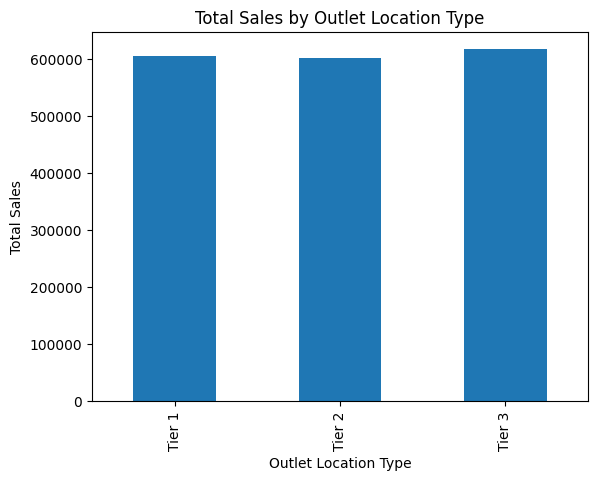

In [ ]:
import matplotlib.pyplot as plt

df.groupby("Outlet_Location_Type")["Item_Outlet_Sales"].sum().plot(kind="bar")

plt.title("Total Sales by Outlet Location Type")
plt.xlabel("Outlet Location Type")
plt.ylabel("Total Sales")

plt.show()

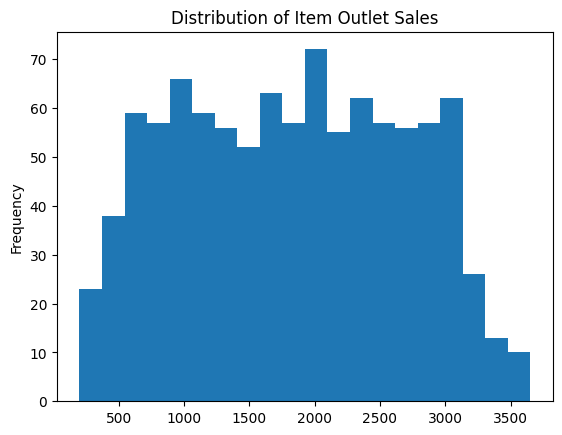

In [ ]:
df["Item_Outlet_Sales"].plot(kind="hist", bins=20)

plt.title("Distribution of Item Outlet Sales")

plt.show()

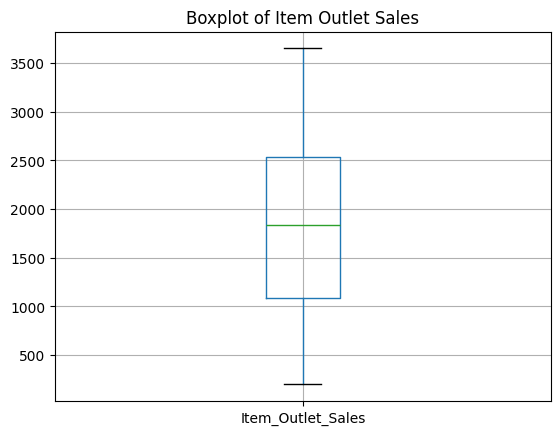

In [ ]:
df.boxplot(column="Item_Outlet_Sales")

plt.title("Boxplot of Item Outlet Sales")

plt.show()

Insight 1

The average (mean) sales value shows the general sales performance across all items.

Insight 2

If the mean is higher than the median, it suggests that some items have very high sales, creating outliers.

Insight 3

The bar chart shows which outlet location type generates the highest total sales.

Insight 4

The histogram shows the distribution of sales and helps identify whether most items have low or high sales.